<a href="https://colab.research.google.com/github/khu3086/FastAICourse/blob/main/Lec1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification Notebook

This notebook demonstrates how to create a simple image classifier using `fastai` and `DuckDuckGo` image search.

## Internet Connection Check

This cell verifies that your Colab environment has internet access, which is crucial for downloading packages and images.

**Note:** Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail. This code is only here to check that your internet is enabled. Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

In [11]:
import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

## Step 1: Set up Image Searching and Downloading

We'll use the `ddgs` library to search for images on DuckDuckGo and `fastai` for downloading and processing them. We need to install `ddgs` first.

In [12]:
!pip install -qqq ddgs
from ddgs import DDGS # DuckDuckGo has changed the api so we need to update
from fastcore.all import *
from fastai.vision.all import *
from pathlib import Path
import time

### `search_images` Function

This function uses `ddgs` to search for image URLs. A `time.sleep(1)` delay is included to mitigate rate-limiting issues from DuckDuckGo. If you encounter `RatelimitException`, you might need to increase the delay or wait a while before trying again.

In [13]:
def search_images(keywords, max_images=200):
    """Searches DuckDuckGo for image URLs based on keywords."""
    res = []
    for _ in range(max_images):
        try:
            results = list(DDGS().images(keywords, max_results=1))
            if results:
                res.extend(L(results).itemgot('image'))
            else:
                print(f"No image found for '{keywords}' in this iteration.")
        except Exception as e:
            print(f"Error searching for '{keywords}': {e}")
        time.sleep(1) # Add a 1-second delay between requests to prevent rate limiting
    return res

### Test Image Search and Download

Let's test our `search_images` function by searching for a single 'bird photo' and downloading it. Then we'll display a thumbnail of the image.

Found URL: https://images.pexels.com/photos/20752281/pexels-photo-20752281/free-photo-of-brown-bird-among-grass.jpeg?auto=compress&cs=tinysrgb&w=1200


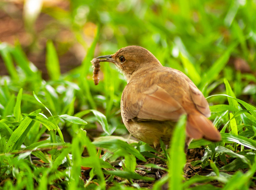

In [14]:
from fastdownload import download_url

# Search for one bird photo
urls = search_images('bird photos', max_images=1)
if urls:
    print(f"Found URL: {urls[0]}")
    # Download the image
    dest = 'bird.jpg'
    download_url(urls[0], dest, show_progress=False)

    # Open and display a thumbnail of the image
    im = Image.open(dest)
    display(im.to_thumb(256,256))
else:
    print("Could not find any bird images.")

Found URL: https://wallpapercave.com/wp/wp3123575.jpg


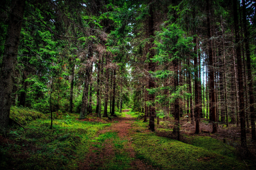

In [15]:
# Search for one forest photo and download it
forest_urls = search_images('forest photos', max_images=1)
if forest_urls:
    print(f"Found URL: {forest_urls[0]}")
    download_url(forest_urls[0], 'forest.jpg', show_progress=False)
    display(Image.open('forest.jpg').to_thumb(256,256))
else:
    print("Could not find any forest images.")

### Download Multiple Images for Training

Now, we'll download a larger set of images for both 'forest' and 'bird' categories. These will be stored in separate subfolders. We also resize them to a maximum size to standardize our dataset.

In [16]:
searches = 'forest','bird' # Define the categories for our classifier
path = Path('bird_or_not') # This will be the root directory for our images

for o in searches:
    dest = (path/o) # Create a subdirectory for each category (e.g., 'bird_or_not/forest', 'bird_or_not/bird')
    dest.mkdir(exist_ok=True, parents=True) # Create directories if they don't exist

    print(f"Searching for '{o} photo'...")
    # Download images for the current category. We'll download more here for training.
    # Note: `max_images` can be increased for more data, but be mindful of rate limits.
    download_images(dest, urls=search_images(f'{o} photo', max_images=50)) # Downloading 50 images per category

    time.sleep(5) # Add a longer delay between categories to reduce risk of rate limiting

    # Resize images to a maximum size of 400 pixels to standardize and save space
    resize_images(path/o, max_size=400, dest=path/o)
print("Image download and resizing complete!")

Searching for 'forest photo'...
Searching for 'bird photo'...
Image download and resizing complete!


## Step 2: Prepare Data and Train Model

### Clean Data

Some downloaded images might be corrupted or incomplete. `verify_images` and `unlink` help us remove these problematic files, which could cause errors during training.

In [17]:
# Verify images and remove any that are corrupted
failed = verify_images(get_image_files(path))
if failed:
    print(f"Found {len(failed)} failed images. Removing them...")
    failed.map(Path.unlink)
else:
    print("No failed images found.")
print(f"Number of failed images removed: {len(failed)}")

No failed images found.
Number of failed images removed: 0


### Create DataLoaders

`DataLoaders` are central to `fastai` for managing training and validation data. We use a `DataBlock` to define how our data is structured and processed.

DataLoaders created and sample batch displayed.


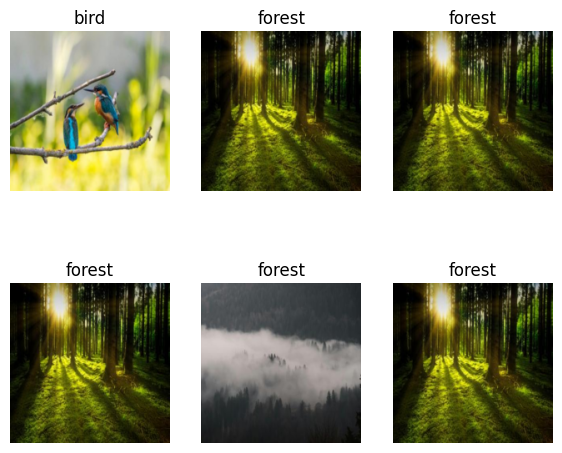

In [18]:
# Create DataLoaders for our image classification task
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

# Display a batch of images from the DataLoaders to visualize our data
dls.show_batch(max_n=6, figsize=(7,6))
print("DataLoaders created and sample batch displayed.")

Here what each of the DataBlock parameters means:

*   `blocks=(ImageBlock, CategoryBlock)`: Specifies that our input is an image and our output is a category.
*   `get_items=get_image_files`: Tells `fastai` to find all image files within our `path`.
*   `splitter=RandomSplitter(valid_pct=0.2, seed=42)`: Divides our dataset into 80% for training and 20% for validation randomly, with a fixed seed for reproducibility.
*   `get_y=parent_label`: Extracts the label (e.g., 'bird', 'forest') from the parent directory name of each image file.
*   `item_tfms=[Resize(192, method='squish')]`: Resizes each image to 192x192 pixels by squishing it. This is applied *before* batching.

### Train the Model

We'll use a pre-trained `resnet18` model, which is a powerful convolutional neural network. `fastai`'s `vision_learner` and `fine_tune` methods make it incredibly easy to adapt this model to our specific task (classifying 'bird' or 'forest').

*   `vision_learner(dls, resnet18, metrics=error_rate)`: Creates a learner object, specifying our data (`dls`), the pre-trained model (`resnet18`), and the metric to track (`error_rate`).
*   `learn.fine_tune(3)`: Fine-tunes the model for 3 epochs. This process takes the pre-trained weights and adjusts them to learn the specific features of our bird/forest images.

In [19]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)
print("Model training complete.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.678457,0.041347,0.000000,00:03


epoch,train_loss,valid_loss,error_rate,time
0,0.223559,0.000635,0.000000,00:01
1,0.194006,0.072743,0.000000,00:01
2,0.135687,0.005451,0.000000,00:01


Model training complete.


## Step 3: Use Our Model for Prediction

Now that our model is trained, let's use it to predict whether the `bird.jpg` image we downloaded earlier is indeed a bird.

In [23]:
# Make a prediction on the 'bird.jpg' image
is_bird,_,probs = learn.predict('bird.jpg')

# Print the results
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[learn.dls.vocab.o2i['bird']]:.4f}") # Get probability for 'bird' class

This is a: bird.
Probability it's a bird: 1.0000
